In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/life_satisfaction_canadian_survey_ml.csv")

df_ml.head()

,Gender,Marital_status,Household,Age,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Sense_belonging,Weight_state,BMI_18_above,Sleep_apnea,High_BP,High_cholestrol,Diabetic,Fatigue_syndrome,Mood_disorder,Anxiety_disorder,Respiratory_chronic_con,Musculoskeletal_con,Cardiovascular_con,Health_utility_indx,Pain_status,Cannabies_use,Aboriginal_identity,Birth_country,Immigrant,Food_security,Income_source,Total_income,Marital_status__missing,Household__missing,Edu_level__missing,Gen_health_state__missing,Life_satisfaction__missing,Mental_health_state__missing,Stress_level__missing,Sense_belonging__missing,Weight_state__missing,BMI_18_above__missing,Sleep_apnea__missing,High_BP__missing,High_cholestrol__missing,Diabetic__missing,Fatigue_syndrome__missing,Mood_disorder__missing,Anxiety_disorder__missing,Respiratory_chronic_con__missing,Musculoskeletal_con__missing,Cardiovascular_con__missing,Health_utility_indx__missing,Pain_status__missing,Cannabies_use__missing,Aboriginal_identity__missing,Birth_country__missing,Immigrant__missing,Food_security__missing,Income_source__missing,Total_income__missing
0,2.0,1.0,2.0,3.0,3.0,3.0,9.0,3.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,2.0,5.0,2.0,3.0,4.0,3.0,3.0,3.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,2.0,1.0,5.0,1.0,2.0,7.0,3.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,2.0,1.0,5.0,1.0,3.0,8.0,3.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,2.0,1.0,4.0,3.0,5.0,0.0,5.0,4.0,3.0,3.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df_ml = df_ml[df_ml["Life_satisfaction__missing"] == 0]

# Target variable: Life satisfaction on the original 0–10 scale
y = df_ml["Life_satisfaction"].astype(int)

# Predictors: drop the target and its missingness indicator
X = df_ml.drop(columns=[
    "Life_satisfaction",
    "Life_satisfaction__missing"
], errors="ignore")

print("Life_satisfaction in X:", "Life_satisfaction" in X.columns)
print("Life_satisfaction__missing in X:", "Life_satisfaction__missing" in X.columns)


Life_satisfaction in X: False
Life_satisfaction__missing in X: False


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2 = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Results
MAE: 0.9559536820709589
RMSE: 1.2961787257200168
R2: 0.39686482828950864


In [10]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lin
})

comparison.head(10)

,Actual,Predicted
17765,6,7.902982
8932,8,6.872175
23915,10,6.182169
21284,7,7.637720
24468,8,8.555662
21848,10,10.358466
3883,8,7.734926
42155,8,7.720956
27146,7,8.128629
71361,10,9.157473


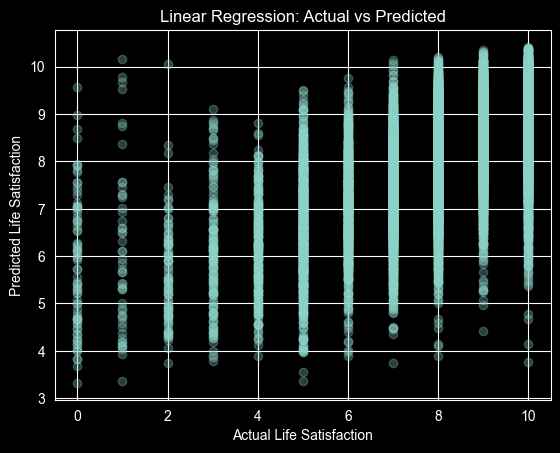

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [12]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 0.9715467069300863
RMSE: 1.313607123494405
R2: 0.3805362936358109


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_tree
})

comparison.head(10)

,Actual,Predicted
17765,6,7.511737
8932,8,7.337733
23915,10,7.993086
21284,7,8.501987
24468,8,8.459638
21848,10,9.680774
3883,8,7.793162
42155,8,7.662162
27146,7,7.972471
71361,10,8.917012


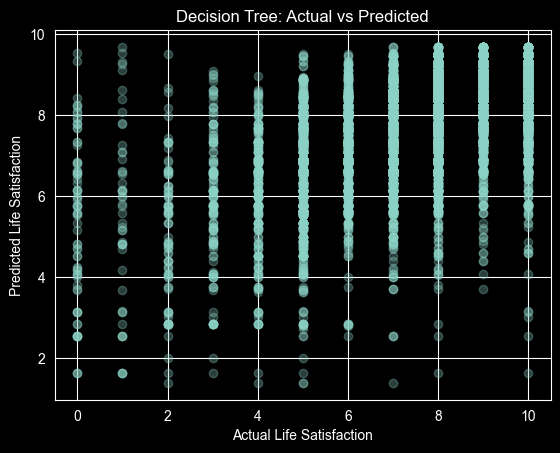

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 0.9632387313119389
RMSE: 1.293697571264859
R2: 0.39917166948435356


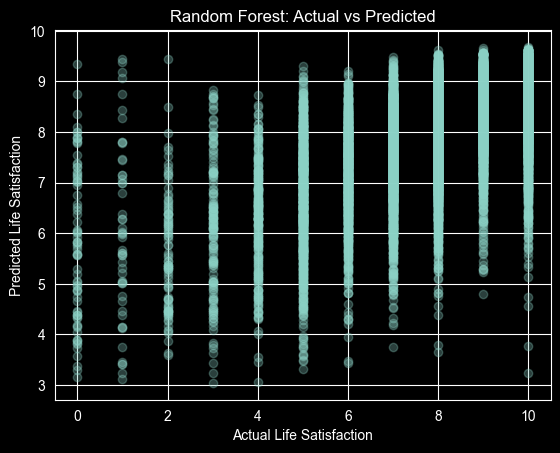

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [19]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Mental_health_state             0.254410
Gen_health_state                0.195862
Stress_level                    0.111181
Health_utility_indx             0.061550
Sense_belonging                 0.060484
Mood_disorder                   0.039949
Pain_status                     0.030408
Marital_status                  0.024400
Food_security                   0.020149
Total_income                    0.019855
Anxiety_disorder                0.019477
Household                       0.016664
Age                             0.013724
Weight_state                    0.011191
Health_utility_indx__missing    0.009709
dtype: float64

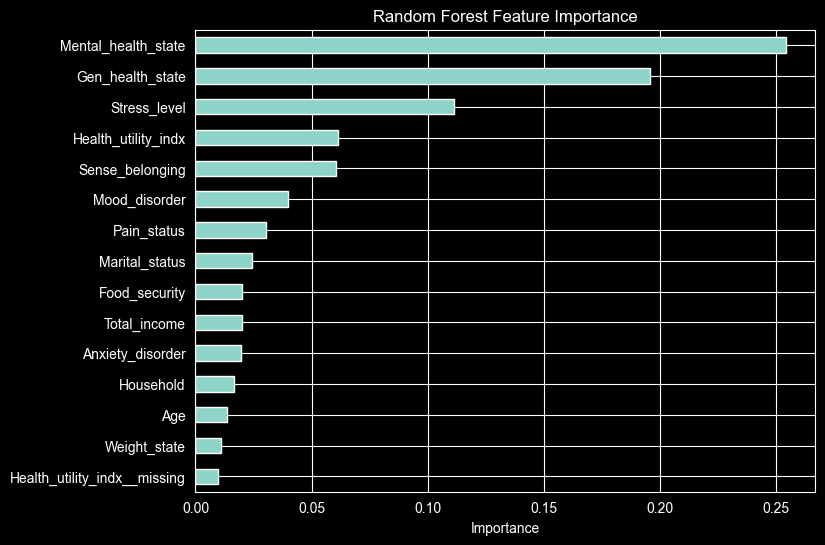

In [20]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 0.9454688429832458
RMSE: 1.2789518633650492
R2: 0.4127901792526245


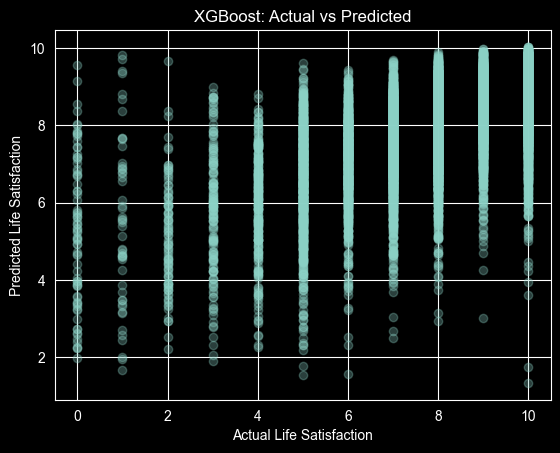

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [24]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(15)

Mental_health_state             0.191389
Gen_health_state                0.137923
Mood_disorder                   0.123535
Health_utility_indx             0.089763
Stress_level                    0.051239
Sense_belonging                 0.050167
Marital_status                  0.049381
Pain_status                     0.039578
Health_utility_indx__missing    0.026468
Household                       0.020403
Food_security                   0.016291
Weight_state                    0.011437
Gender                          0.010838
Immigrant                       0.009063
Birth_country                   0.008451
dtype: float32

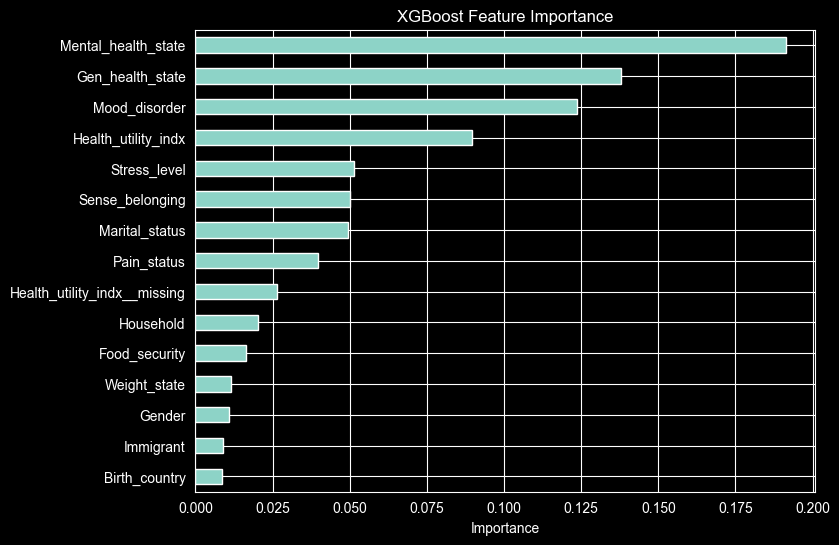

In [25]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()